In [1]:
import numpy as np
import json
from collections import defaultdict
from itertools import product
import matplotlib.pyplot as plt

In [28]:
# Load the JSONL file
RFS_articles = []
with open('RFS_articles.jsonl', 'r') as f:
    for line in f:
        try:
            article = json.loads(line)
            RFS_articles.append(article)
        except json.JSONDecodeError as e:
            print(f"Error reading line: {e}")
            continue


In [5]:
RFS_articles[-1]

{'doi': '10.1093/rfs/hhr100',
 'type': 'journal-article',
 'published_date': '2012-04-01',
 'title': 'Precarious Politics and Return Volatility',
 'journal': 'Review of Financial Studies',
 'volume': '25',
 'issue': '4',
 'authors': [['Maria', 'Boutchkova'],
  ['Hitesh', 'Doshi'],
  ['Art', 'Durnev'],
  ['Alexander', 'Molchanov']],
 'references': [{'reference_type': 'article',
   'doi': '10.1086/432166',
   'year': 2005,
   'title': 'Unbundling Institutions',
   'journal': 'Journal of Political Economy',
   'volume': '113',
   'issue': '5',
   'authors': [['Daron', 'Acemoglu'], ['Simon', 'Johnson']],
   'working_paper_institution': None,
   'book_title': None,
   'chapter_title': None},
  {'reference_type': 'article',
   'doi': '10.2307/2118470',
   'year': 1994,
   'title': 'Distributive Politics and Economic Growth',
   'journal': 'The Quarterly Journal of Economics',
   'volume': '109',
   'issue': '2',
   'authors': [['A.', 'Alesina'], ['D.', 'Rodrik']],
   'working_paper_instituti

In [29]:
# Remove articles with non_article titles
titles_to_filter = {"editorial board", "publishers note", "advert:", "call for papers:", "table of contents", "forthcoming articles", "cover", "index", "acknowledgments", "erratum", "acknowledgements", "joint editorial", "a note from the editor", "annual report", "oup accepted manuscript"}

initial_count = len(RFS_articles)

RFS_articles = [
    article for article in RFS_articles 
    if article.get('title') is not None and
    not any(non_article.lower() in article.get('title', '').lower() for non_article in titles_to_filter)
]

# Remove articles with title "Index" or "Contents" (case insensitive)
RFS_articles = [article for article in RFS_articles if article.get('title', '').lower() != "index"]
RFS_articles = [article for article in RFS_articles if article.get('title', '').lower() != "contents"]

final_count = len(RFS_articles)
removed_count = initial_count - final_count
print(f"Removed {removed_count} non-article entries out of {initial_count} total entries ({(removed_count/initial_count)*100:.1f}%)")

Removed 414 non-article entries out of 2701 total entries (15.3%)


### Articles per Year

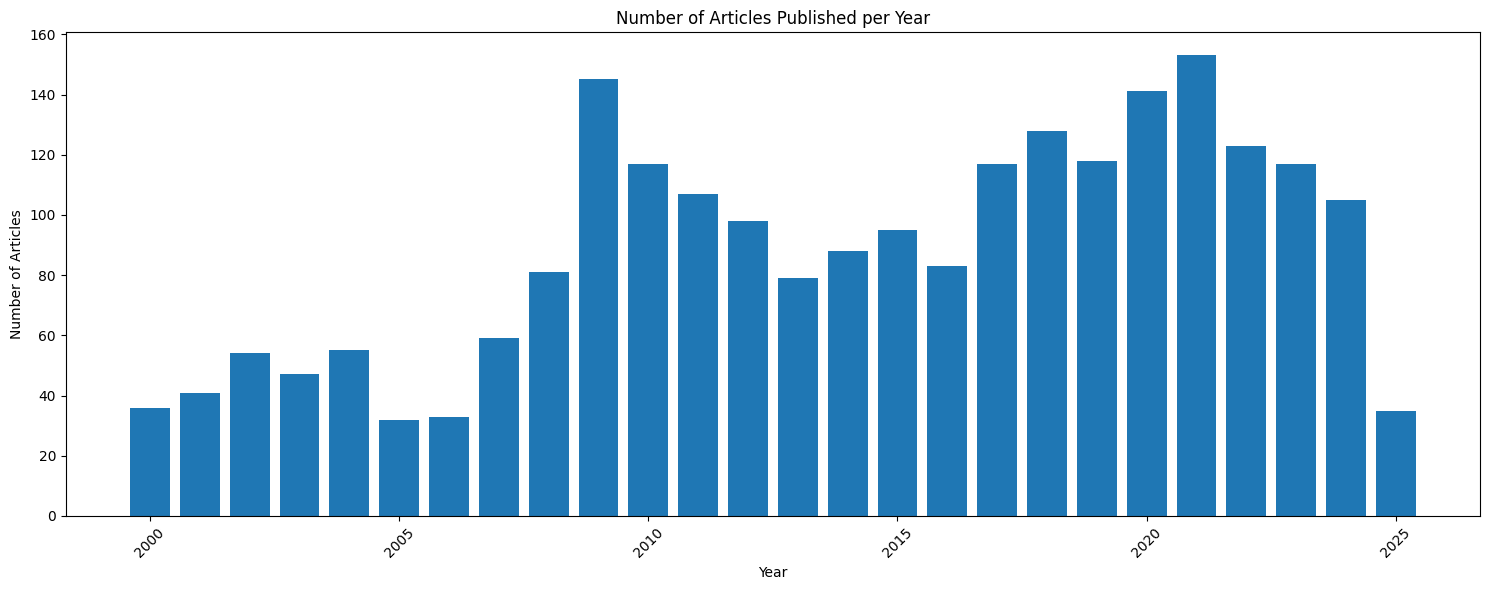

Year: Number of Articles
2000: 36
2001: 41
2002: 54
2003: 47
2004: 55
2005: 32
2006: 33
2007: 59
2008: 81
2009: 145
2010: 117
2011: 107
2012: 98
2013: 79
2014: 88
2015: 95
2016: 83
2017: 117
2018: 128
2019: 118
2020: 141
2021: 153
2022: 123
2023: 117
2024: 105
2025: 35


In [31]:
year_article_count = defaultdict(int)

for article in RFS_articles:
    year = int(article['published_date'][:4]) if article['published_date'] else None
    if year:
        year_article_count[year] += 1
    

# Sort the dictionary by year
sorted_year_article_count = dict(sorted(year_article_count.items()))

# Create bar plot

plt.figure(figsize=(15, 6))
plt.bar(sorted_year_article_count.keys(), sorted_year_article_count.values())
plt.xlabel('Year')
plt.ylabel('Number of Articles')
plt.title('Number of Articles Published per Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print the results
print("Year: Number of Articles")
for year, count in sorted_year_article_count.items():
    print(f"{year}: {count}")


### Average Reference per Article by Year

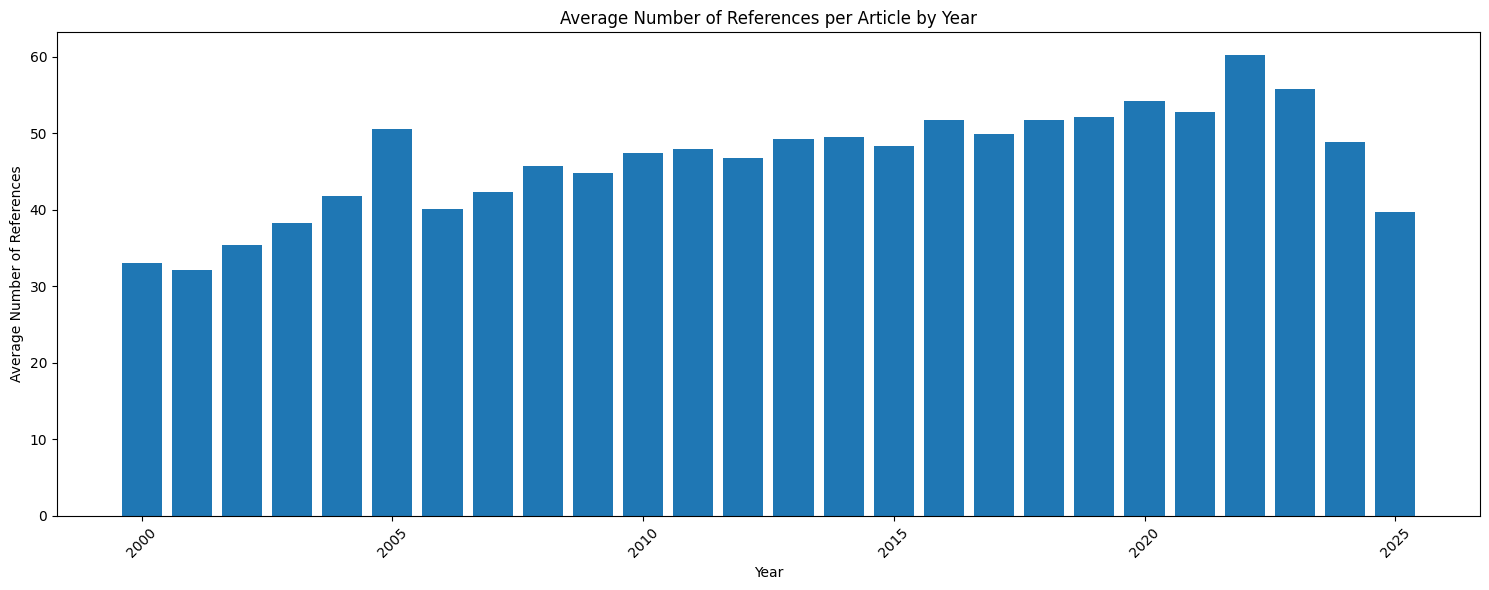

Year: Avg Reference Count
2000: 33.00
2001: 32.07
2002: 35.43
2003: 38.28
2004: 41.75
2005: 50.53
2006: 40.06
2007: 42.36
2008: 45.73
2009: 44.76
2010: 47.44
2011: 47.89
2012: 46.76
2013: 49.28
2014: 49.55
2015: 48.29
2016: 51.65
2017: 49.94
2018: 51.77
2019: 52.13
2020: 54.20
2021: 52.78
2022: 60.15
2023: 55.82
2024: 48.86
2025: 39.71


In [32]:
year_ref_counts = defaultdict(list)

for article in RFS_articles:
    year = int(article['published_date'][:4]) if article['published_date'] else None
    if year:
        year_article_count[year] += 1
    ref_count = len(article.get('references', []))
    
    year_ref_counts[year].append(ref_count)
avg_ref_counts = {year: np.mean(counts) for year, counts in year_ref_counts.items()}

# Sort the dictionary by year
sorted_avg_ref_counts = dict(sorted(avg_ref_counts.items()))

# Create bar plot
plt.figure(figsize=(15, 6))
plt.bar(sorted_avg_ref_counts.keys(), sorted_avg_ref_counts.values())
plt.xlabel('Year')
plt.ylabel('Average Number of References')
plt.title('Average Number of References per Article by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Year: Avg Reference Count")
for year in sorted(avg_ref_counts.keys()):
    print(f"{year}: {avg_ref_counts[year]:.2f}")

### Average Age of Publication of Cited Papers (when cited) by Year

Age of publication in this case means the number of years from the time the paper was originally published to the time it was cited, rounded down to the nearest year.

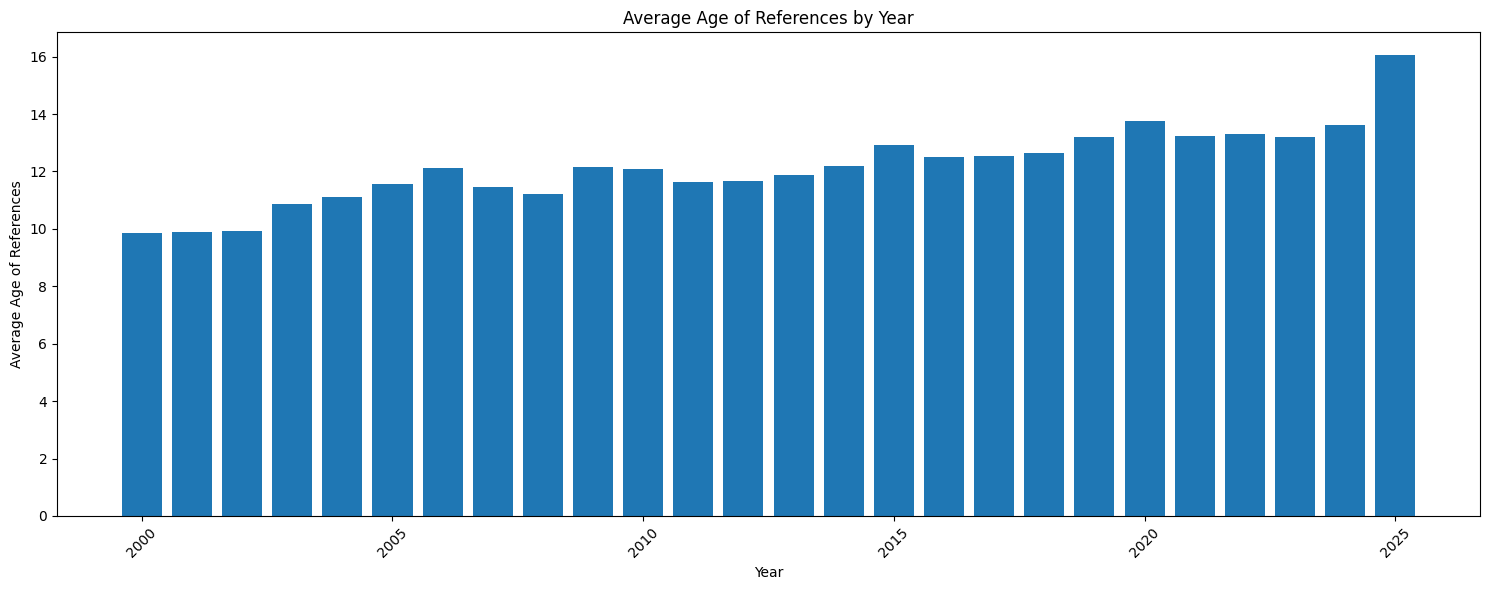

Year: Avg Reference Age
2000: 9.87
2001: 9.89
2002: 9.91
2003: 10.88
2004: 11.10
2005: 11.56
2006: 12.11
2007: 11.46
2008: 11.20
2009: 12.15
2010: 12.07
2011: 11.65
2012: 11.66
2013: 11.88
2014: 12.19
2015: 12.91
2016: 12.49
2017: 12.54
2018: 12.63
2019: 13.19
2020: 13.76
2021: 13.25
2022: 13.30
2023: 13.21
2024: 13.62
2025: 16.04


In [33]:
reference_age_by_year = defaultdict(list)

for article in RFS_articles:
    article_year = int(article['published_date'][:4]) if article['published_date'] else None
    if article_year is None:
        article_year = 2000 # this is manually checked
    if article_year:
        year_article_count[article_year] += 1
    reference_ages = []
    
    for ref in article.get('references', []):
        if 'year' in ref and ref['year'] is not None:
            try:
                ref_year = int(ref['year'])
                age = article_year - ref_year
                reference_ages.append(age)
            except ValueError:
                continue
    
    if reference_ages:
        avg_age = np.mean(reference_ages)
        reference_age_by_year[article_year].append(avg_age)

avg_reference_age_by_year = {year: np.mean(ages) for year, ages in reference_age_by_year.items()}

# Sort the dictionary by year
sorted_avg_reference_age = dict(sorted(avg_reference_age_by_year.items()))

# Create bar plot
plt.figure(figsize=(15, 6))
plt.bar(sorted_avg_reference_age.keys(), sorted_avg_reference_age.values())
plt.xlabel('Year')
plt.ylabel('Average Age of References')
plt.title('Average Age of References by Year')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Year: Avg Reference Age")
for year in sorted(avg_reference_age_by_year.keys()):
    print(f"{year}: {avg_reference_age_by_year[year]:.2f}")


### Average Top Journal Share of Cited Papers by Year (share of all references)

Use AER, Econometrica, QJE, Review of Economics Studies, Journal of Political Economy, JF, JFE, RFS

c:\Users\wangac\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\wangac\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


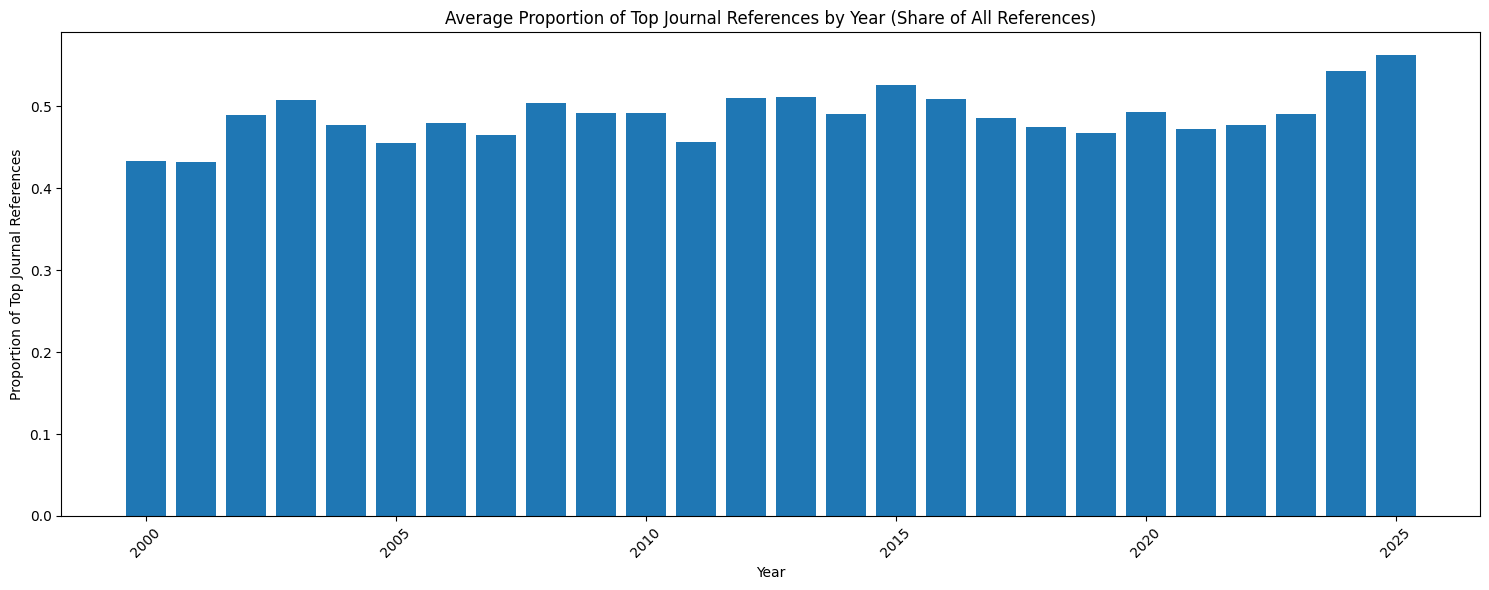

Year: Avg Proportion of Top Journal References (Share of All References)
2000: 0.4339
2001: 0.4326
2002: 0.4899
2003: 0.5080
2004: 0.4768
2005: 0.4556
2006: 0.4798
2007: 0.4647
2008: 0.5040
2009: 0.4917
2010: 0.4920
2011: 0.4570
2012: 0.5097
2013: 0.5111
2014: 0.4909
2015: 0.5268
2016: 0.5086
2017: 0.4864
2018: 0.4748
2019: 0.4671
2020: 0.4934
2021: 0.4727
2022: 0.4767
2023: 0.4907
2024: 0.5438
2025: 0.5624


In [41]:
def add_period_variants(names):
    expanded = set()
    for name in names:
        words = name.split()
        for i in range(len(words)):
            # Generate all combinations of with/without periods for each word
            variants = [(w, w + '.') for w in words]
            for combo in product(*variants):
                expanded.add(' '.join(combo))
    return expanded

jf_names = {"j finan", "journal finan", "j financ", "journal financ", "j finance", "journal finance", "j of finan", "journal of finan", "j of financ", "journal of financ", "j of finance", "journal of finance"}
jfe_names = {"j finan econ", "journal finan econ", "j financ econ", "journal financ econ", "j finance econ", "journal finance econ", "j of finan econ", "journal of finan econ", "j of financ econ", "journal of financ econ", "j of finance econ", "journal of finance econ","journal of financial economics"}
rfs_names = {"rev finan stud", "review finan stud", "rev financ stud", "review financ stud", "rev finance stud", "review finance stud", "rev of finan stud", "review of finan stud", "rev of financ stud", "review of financ stud", "rev of finance stud", "review of finance stud", "review of financial studies"}
aer_names = {"am econ rev", "ame econ rev", "amer econ rev", "american econ rev", "am econ review", "ame econ review", "amer econ review", "american econ review", "american economic review"}
econometrica_names = {"econometrica"}
qje_names = {"q j econ", "q j of econ", "q j economics", "q j of economics", "quart j econ", "quart j of econ", "quart j economics", "quart j of economics", "quarterly j econ", "quarterly j of econ", "quarterly j economnics", "quarterly j of economnics", "quarterly journal economics", "quarterly journal of economics"}
res_names = {"rev econ stud", "review of economics studies"}
jpe_names = {"j polit econ", "j polit economics", "j political econ", "j political economics", "journal of political economy"}




jf_names = add_period_variants(jf_names)
jfe_names = add_period_variants(jfe_names)
rfs_names = add_period_variants(rfs_names)
aer_names = add_period_variants(aer_names)
econometrica_names = add_period_variants(econometrica_names)
qje_names = add_period_variants(qje_names)
res_names = add_period_variants(res_names)
jpe_names = add_period_variants(jpe_names)

# Rebuild top_journals with expanded variants
top_journals = jf_names | jfe_names | rfs_names | aer_names | econometrica_names | qje_names | res_names | jpe_names | {f"the {name}" for name in (jf_names | jfe_names | rfs_names | aer_names | econometrica_names | qje_names | res_names | jpe_names)}

top_journal_proportions = defaultdict(lambda: {'all': [], 'published': []})

for article in RFS_articles:
    year = int(article['published_date'][:4]) if article['published_date'] else None
    if year:
        year_article_count[year] += 1
    total_refs = len(article.get('references', []))
    top_journal_refs = sum(1 for ref in article.get('references', []) if ref.get('journal') is not None and ref.get('journal').lower() in top_journals)
    published_journal_refs = sum(1 for ref in article.get('references', []) if ref.get('type') == 'article')
    
    if total_refs > 0:
        top_journal_proportions[year]['all'].append(top_journal_refs / total_refs)
    if published_journal_refs > 0:
        top_journal_proportions[year]['published'].append(top_journal_refs / published_journal_refs)

avg_proportions = {year: {
    'all': np.mean(props['all']),
    'published': np.mean(props['published'])
} for year, props in top_journal_proportions.items()}

# Sort the dictionary by year
sorted_avg_proportions = dict(sorted({year: props['all'] for year, props in avg_proportions.items()}.items()))

# Create bar plot
plt.figure(figsize=(15, 6))
plt.bar(sorted_avg_proportions.keys(), sorted_avg_proportions.values())
plt.xlabel('Year')
plt.ylabel('Proportion of Top Journal References')
plt.title('Average Proportion of Top Journal References by Year (Share of All References)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Year: Avg Proportion of Top Journal References (Share of All References)")
for year in sorted(avg_proportions.keys()):
    print(f"{year}: {avg_proportions[year]['all']:.4f}")


In [36]:
# Count frequency of reference types
reference_type_counts = defaultdict(int)
total_references = 0

for article in RFS_articles:
    for ref in article.get('references', []):
        ref_type = ref.get('reference_type')
        if ref_type:
            reference_type_counts[ref_type] += 1
            total_references += 1

# Print frequencies and percentages
print("\nReference Type Frequencies:")
print("-" * 50)
print(f"{'Reference Type':<20} {'Count':>8} {'Percentage':>12}")
print("-" * 50)
for ref_type, count in sorted(reference_type_counts.items()):
    percentage = (count / total_references) * 100
    print(f"{ref_type:<20} {count:>8} {percentage:>11.2f}%")
print("-" * 50)
print(f"{'Total':<20} {total_references:>8}")



Reference Type Frequencies:
--------------------------------------------------
Reference Type          Count   Percentage
--------------------------------------------------
article                100829       94.53%
book                     2394        2.24%
report                      1        0.00%
working_paper            3441        3.23%
--------------------------------------------------
Total                  106665
